In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
 
print("✓ Imports complete")

✓ Imports complete


In [2]:
from vrp_adaptive import run_two_layer_routing_with_mdp
 
print("Running path planning algorithm...")
print("=" * 70)
 
# Run the complete planning
results = run_two_layer_routing_with_mdp()
 
# Unpack all results
(tour_sequence, refined_paths, refined_costs, refined_distributions, 
 mdp, Z_clean, Z_with_obstacles, path_matrix) = results
 
print("\n" + "=" * 70)
print("✓ PLANNING COMPLETE!")
print("=" * 70)
print(f"Tour sequence: {len(tour_sequence)} waypoints")
print(f"Refined paths: {len(refined_paths)} segments")
print(f"Clean grid: {Z_clean.shape}")
print(f"Grid with obstacles: {Z_with_obstacles.shape}")
print(f"Obstacles added: {np.sum(Z_with_obstacles > 1e5)}")
 

Running path planning algorithm...
Grid size: 178 x 30
Total grid nodes: 5340

Start node: (0, 0)
Target sites (12): [(104, 2), (90, 22), (63, 1), (45, 11), (105, 10), (157, 25), (77, 13), (151, 1), (75, 18), (104, 22), (157, 13), (2, 17)]
Total nodes to visit: 13
Layer 1: Computing A* Pairwise Costs (Coarse Grid)
  (0, 0) -> (104, 2): cost=11026.4400, path_length=122, nodes_explored=4887
  (0, 0) -> (90, 22): cost=10143.5400, path_length=111, nodes_explored=4682
  (0, 0) -> (63, 1): cost=45508.5900, path_length=76, nodes_explored=9484
  (0, 0) -> (45, 11): cost=3374.6400, path_length=49, nodes_explored=2424
  (0, 0) -> (105, 10): cost=12242.8800, path_length=121, nodes_explored=5168
  (0, 0) -> (157, 25): cost=19149.1200, path_length=181, nodes_explored=8407
  (0, 0) -> (77, 13): cost=8269.8300, path_length=92, nodes_explored=3895
  (0, 0) -> (151, 1): cost=18462.4200, path_length=166, nodes_explored=7718
  (0, 0) -> (75, 18): cost=6916.0500, path_length=87, nodes_explored=3396
  (0, 

In [3]:
# Grid setup
ny, nx = Z_clean.shape
Xg, Yg = np.meshgrid(np.arange(nx), np.arange(ny))
 
# Obstacle detection
obstacle_mask = Z_with_obstacles > 1e5
num_obstacles = np.sum(obstacle_mask)
obstacle_coords = np.argwhere(obstacle_mask)
 
# Terrain height calculations
normal_max = Z_clean.max()
normal_min = Z_clean.min()
terrain_range = normal_max - normal_min
 
# Tour coordinates (for MILP visualization)
tour_x = [node[1] for node in tour_sequence]
tour_y = [node[0] for node in tour_sequence]
tour_z = [Z_clean[node[0], node[1]] + 200 for node in tour_sequence]
 
print("✓ Visualization data prepared")
print(f"  Grid size: {ny} × {nx}")
print(f"  Obstacles: {num_obstacles}")
print(f"  Elevation range: [{normal_min:.1f}, {normal_max:.1f}] m")

✓ Visualization data prepared
  Grid size: 178 × 30
  Obstacles: 20
  Elevation range: [-5802.0, -926.0] m



LAYER 1: A* PAIRWISE PATHS (Coarse Grid)


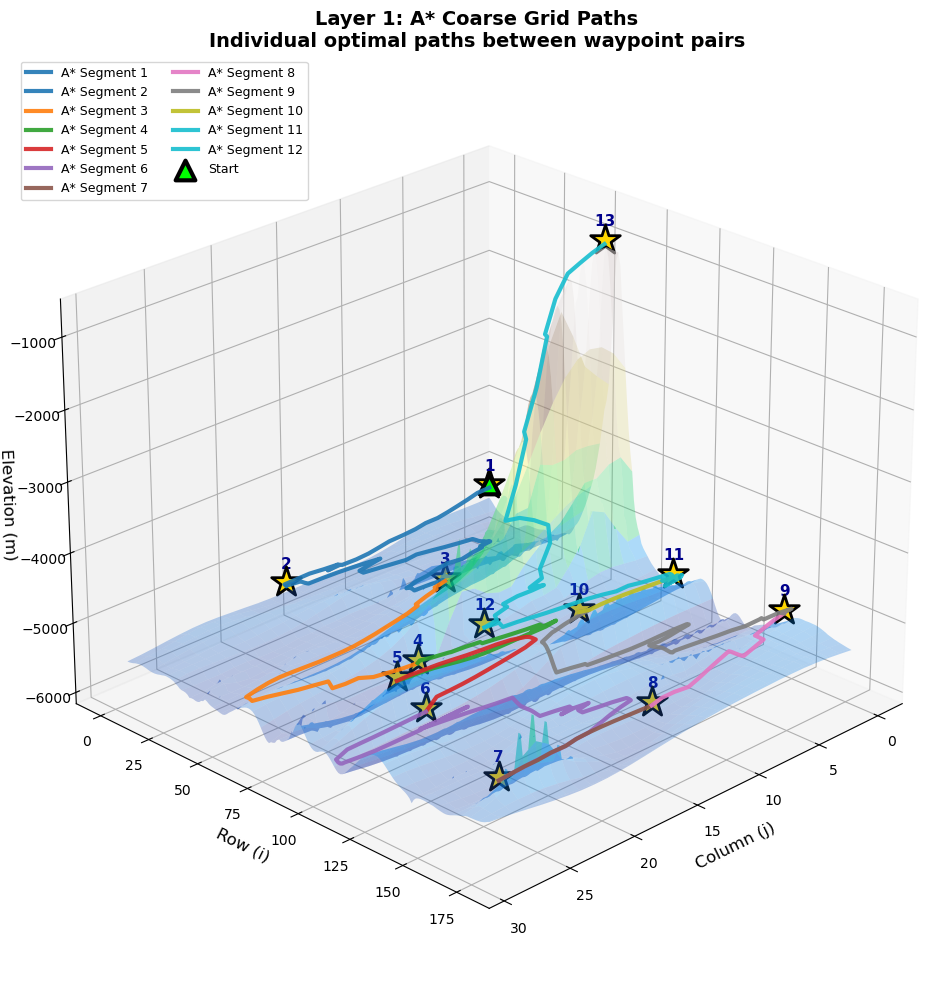

✓ Visualized 12 A* path segments


In [4]:
print("\n" + "=" * 70)
print("LAYER 1: A* PAIRWISE PATHS (Coarse Grid)")
print("=" * 70)
 
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')
 
# Terrain
ax.plot_surface(Xg, Yg, Z_clean, cmap='terrain', alpha=0.3, linewidth=0)
 
# Plot individual A* paths from path_matrix
colors = plt.cm.tab10(np.linspace(0, 1, len(tour_sequence) - 1))
 
for idx in range(len(tour_sequence) - 1):
    start_node = tour_sequence[idx]
    end_node = tour_sequence[idx + 1]
    
    # Get the A* path for this segment
    if (start_node, end_node) in path_matrix:
        astar_path = path_matrix[(start_node, end_node)]
        
        # Extract coordinates
        path_x = [p[1] for p in astar_path]
        path_y = [p[0] for p in astar_path]
        path_z = [Z_clean[p[0], p[1]] + 150 for p in astar_path]
        
        # Plot this A* segment
        ax.plot(path_x, path_y, path_z, color=colors[idx], linewidth=3, 
               alpha=0.9, label=f'A* Segment {idx+1}', zorder=100)
 
# Mark waypoints
for i, node in enumerate(tour_sequence):
    ax.scatter([node[1]], [node[0]], [Z_clean[node[0], node[1]] + 200],
              c='gold', s=500, marker='*', edgecolors='black', 
              linewidth=2, zorder=101)
    ax.text(node[1], node[0], Z_clean[node[0], node[1]] + 400, 
           f'{i+1}', fontsize=11, fontweight='bold', 
           ha='center', color='darkblue')
 
# Start node
ax.scatter([tour_x[0]], [tour_y[0]], [tour_z[0]], 
          c='lime', s=200, marker='^', edgecolors='black', 
          linewidth=3, label='Start', zorder=102)
 
ax.set_title('Layer 1: A* Coarse Grid Paths\nIndividual optimal paths between waypoint pairs', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Column (j)', fontsize=12)
ax.set_ylabel('Row (i)', fontsize=12)
ax.set_zlabel('Elevation (m)', fontsize=12)
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.view_init(elev=25, azim=45)
 
plt.tight_layout()
plt.show()
 
print(f"✓ Visualized {len(tour_sequence) - 1} A* path segments")
 

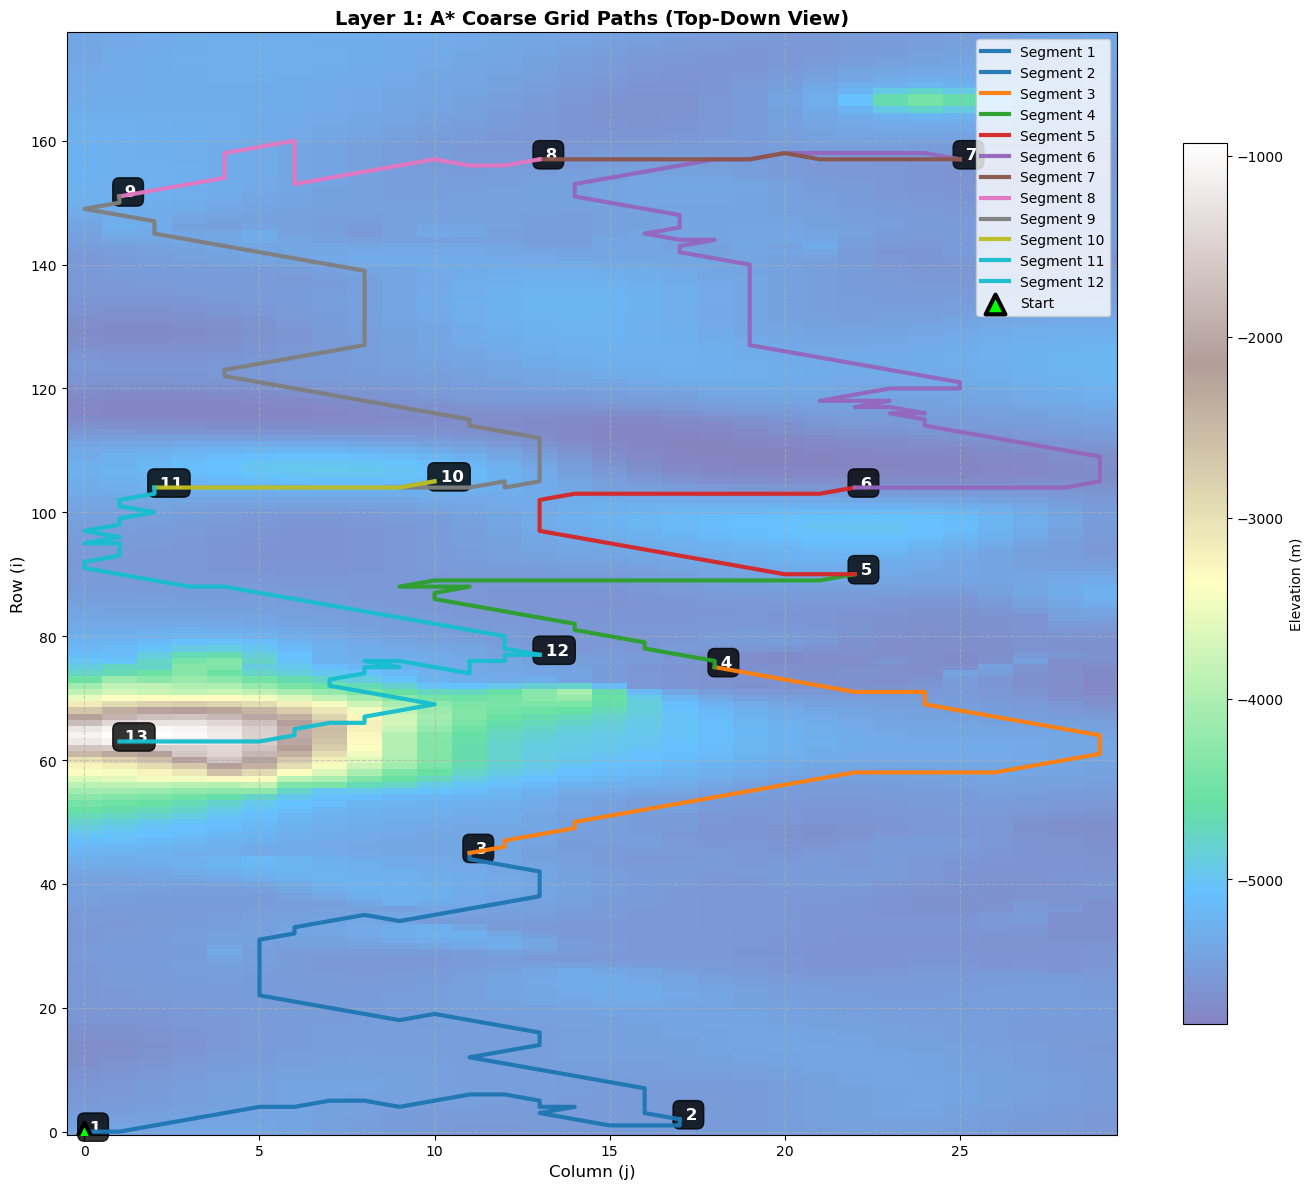

In [5]:
fig, ax = plt.subplots(figsize=(14, 12))
 
# Terrain
im = ax.imshow(Z_clean, cmap='terrain', origin='lower', aspect='auto', alpha=0.6)
plt.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.8)
 
# Plot individual A* paths
colors = plt.cm.tab10(np.linspace(0, 1, len(tour_sequence) - 1))
 
for idx in range(len(tour_sequence) - 1):
    start_node = tour_sequence[idx]
    end_node = tour_sequence[idx + 1]
    
    if (start_node, end_node) in path_matrix:
        astar_path = path_matrix[(start_node, end_node)]
        path_x = [p[1] for p in astar_path]
        path_y = [p[0] for p in astar_path]
        
        ax.plot(path_x, path_y, color=colors[idx], linewidth=3, 
               alpha=0.96, label=f'Segment {idx+1}', zorder=100)
 

 
# Labels
for i, node in enumerate(tour_sequence):
    ax.text(node[1], node[0], f' {i+1}', fontsize=12, 
           fontweight='bold', color='white', 
           bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.8))
 
# Start
ax.scatter([tour_x[0]], [tour_y[0]], c='lime', s=200, marker='^', 
          edgecolors='black', linewidth=3, label='Start', zorder=102)
 
ax.set_title('Layer 1: A* Coarse Grid Paths (Top-Down View)', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Column (j)', fontsize=12)
ax.set_ylabel('Row (i)', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.6, linestyle='--')
 
plt.tight_layout()
plt.show()
 



LAYER 3: MDP LOCAL PLANNING WITH OBSTACLES


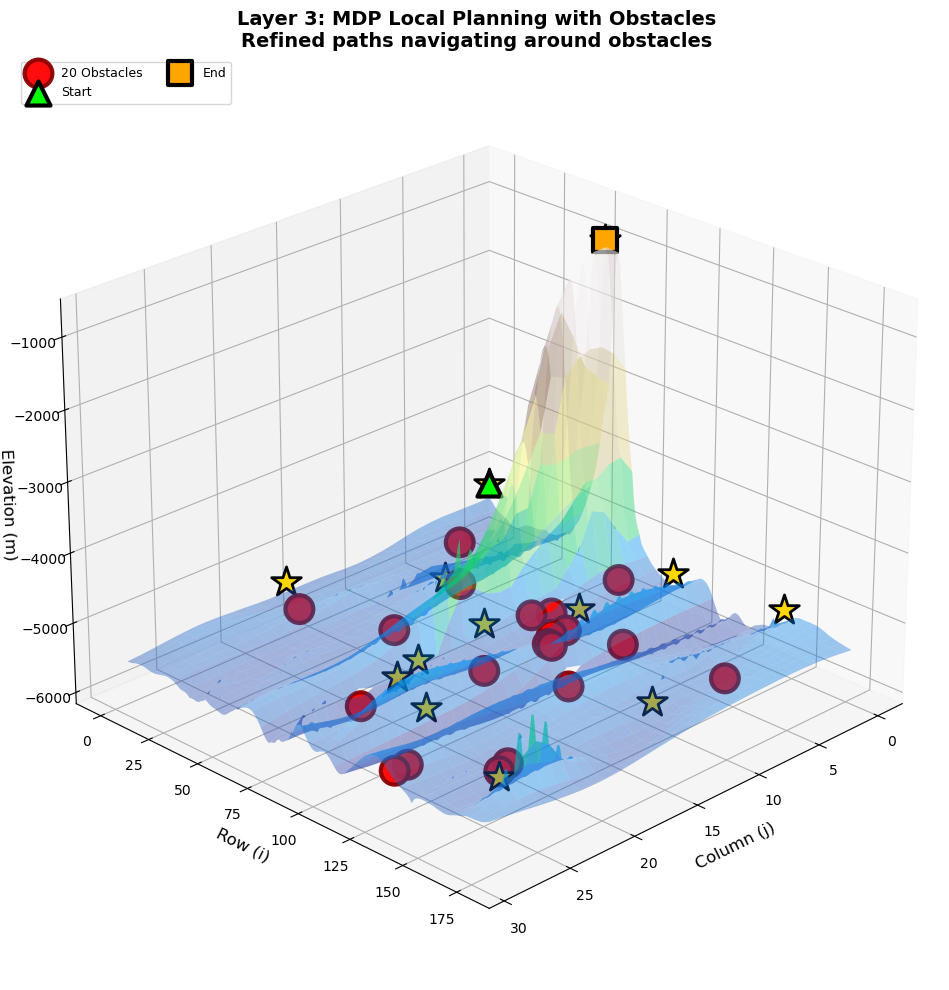

✓ MDP refined paths: 0 segments
   Obstacles avoided: 20


In [6]:
print("\n" + "=" * 70)
print("LAYER 3: MDP LOCAL PLANNING WITH OBSTACLES")
print("=" * 70)
 
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')
 
# Terrain (with obstacles)
Z_display = Z_with_obstacles.copy()
Z_display[obstacle_mask] = np.nan  # Hide obstacle terrain
 
ax.plot_surface(Xg, Yg, Z_display, cmap='terrain', alpha=0.4, linewidth=0)
 
# Obstacles as RED CIRCLES on terrain base
if num_obstacles > 0:
    obs_i = obstacle_coords[:, 0]
    obs_j = obstacle_coords[:, 1]
    obs_z = np.full(len(obstacle_coords), normal_min)  # At base
    
    ax.scatter(obs_j, obs_i, obs_z, c='red', s=400, marker='o',
              edgecolors='darkred', linewidth=3, alpha=0.95,
              label=f'{num_obstacles} Obstacles', zorder=60)
 
# MDP refined paths (curved around obstacles)
colors = plt.cm.rainbow(np.linspace(0, 1, len(tour_sequence) - 1))
 
for idx in range(len(tour_sequence) - 1):
    start_coarse = tour_sequence[idx]
    end_coarse = tour_sequence[idx + 1]
    
    if (start_coarse, end_coarse) in refined_paths:
        fine_path = refined_paths[(start_coarse, end_coarse)]
        
        # Convert fine grid to coarse grid coordinates
        path_x = [p[1] / mdp.refinement_factor for p in fine_path]
        path_y = [p[0] / mdp.refinement_factor for p in fine_path]
        path_z = [mdp.get_elevation(*p) + 200 for p in fine_path]
        
        ax.plot(path_x, path_y, path_z, color=colors[idx], linewidth=4, 
               alpha=0.95, zorder=100, label=f'MDP Segment {idx+1}')
 
# Waypoints
for i, node in enumerate(tour_sequence):
    ax.scatter([node[1]], [node[0]], [Z_clean[node[0], node[1]] + 200],
              c='gold', s=500, marker='*', edgecolors='black', 
              linewidth=2, zorder=101)
 
# Start and end
ax.scatter([tour_x[0]], [tour_y[0]], [tour_z[0]], 
          c='lime', s=300, marker='^', edgecolors='black', 
          linewidth=3, label='Start', zorder=102)
ax.scatter([tour_x[-1]], [tour_y[-1]], [tour_z[-1]], 
          c='orange', s=300, marker='s', edgecolors='black', 
          linewidth=3, label='End', zorder=102)
 
ax.set_title('Layer 3: MDP Local Planning with Obstacles\nRefined paths navigating around obstacles', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Column (j)', fontsize=12)
ax.set_ylabel('Row (i)', fontsize=12)
ax.set_zlabel('Elevation (m)', fontsize=12)
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.view_init(elev=25, azim=45)
 
plt.tight_layout()
plt.show()
 
print(f"✓ MDP refined paths: {len(refined_paths)} segments")
print(f"   Obstacles avoided: {num_obstacles}")
 


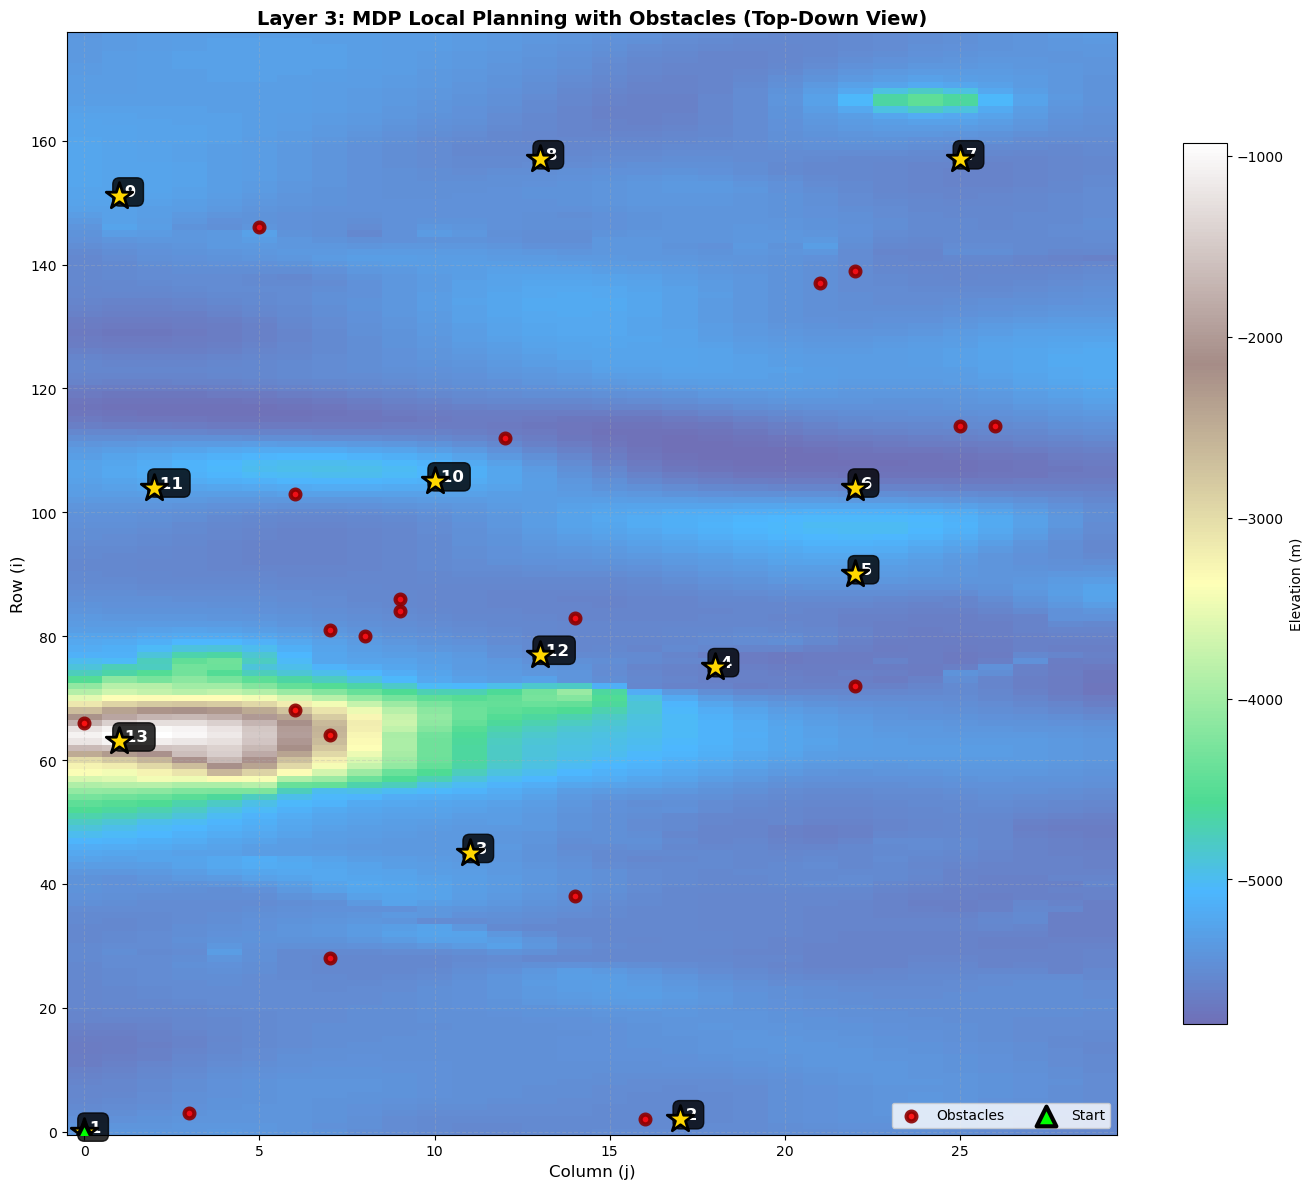

In [7]:
fig, ax = plt.subplots(figsize=(14, 12))
 
# Terrain
im = ax.imshow(Z_clean, cmap='terrain', origin='lower', aspect='auto', alpha=0.7)
plt.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.8)
 
# Obstacles overlay (RED CIRCLES)
if num_obstacles > 0:
    ax.scatter(obstacle_coords[:, 1], obstacle_coords[:, 0], 
              c='red', s=50, marker='o', edgecolors='darkred', 
              linewidth=3, alpha=0.9, label='Obstacles', zorder=200)
 
# MDP refined paths
colors = plt.cm.rainbow(np.linspace(0, 1, len(tour_sequence) - 1))
 
for idx in range(len(tour_sequence) - 1):
    start_coarse = tour_sequence[idx]
    end_coarse = tour_sequence[idx + 1]
    
    if (start_coarse, end_coarse) in refined_paths:
        fine_path = refined_paths[(start_coarse, end_coarse)]
        path_x = [p[1] / mdp.refinement_factor for p in fine_path]
        path_y = [p[0] / mdp.refinement_factor for p in fine_path]
        
        ax.plot(path_x, path_y, color=colors[idx], linewidth=4, 
               alpha=0.95, zorder=100, label=f'Segment {idx+1}')
 
# Waypoints
ax.scatter(tour_x, tour_y, c='gold', s=400, marker='*', 
          edgecolors='black', linewidth=2, zorder=101)
 
# Labels
for i, node in enumerate(tour_sequence):
    ax.text(node[1], node[0], f' {i+1}', fontsize=12, 
           fontweight='bold', color='white', 
           bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.8))
 
# Start
ax.scatter([tour_x[0]], [tour_y[0]], c='lime', s=200, marker='^', 
          edgecolors='black', linewidth=3, label='Start', zorder=102)
 
ax.set_title('Layer 3: MDP Local Planning with Obstacles (Top-Down View)', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Column (j)', fontsize=12)
ax.set_ylabel('Row (i)', fontsize=12)
ax.legend(fontsize=10, loc='lower right', ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')
 
plt.tight_layout()
plt.show()


COMPARISON: MILP Tour vs MDP Refined


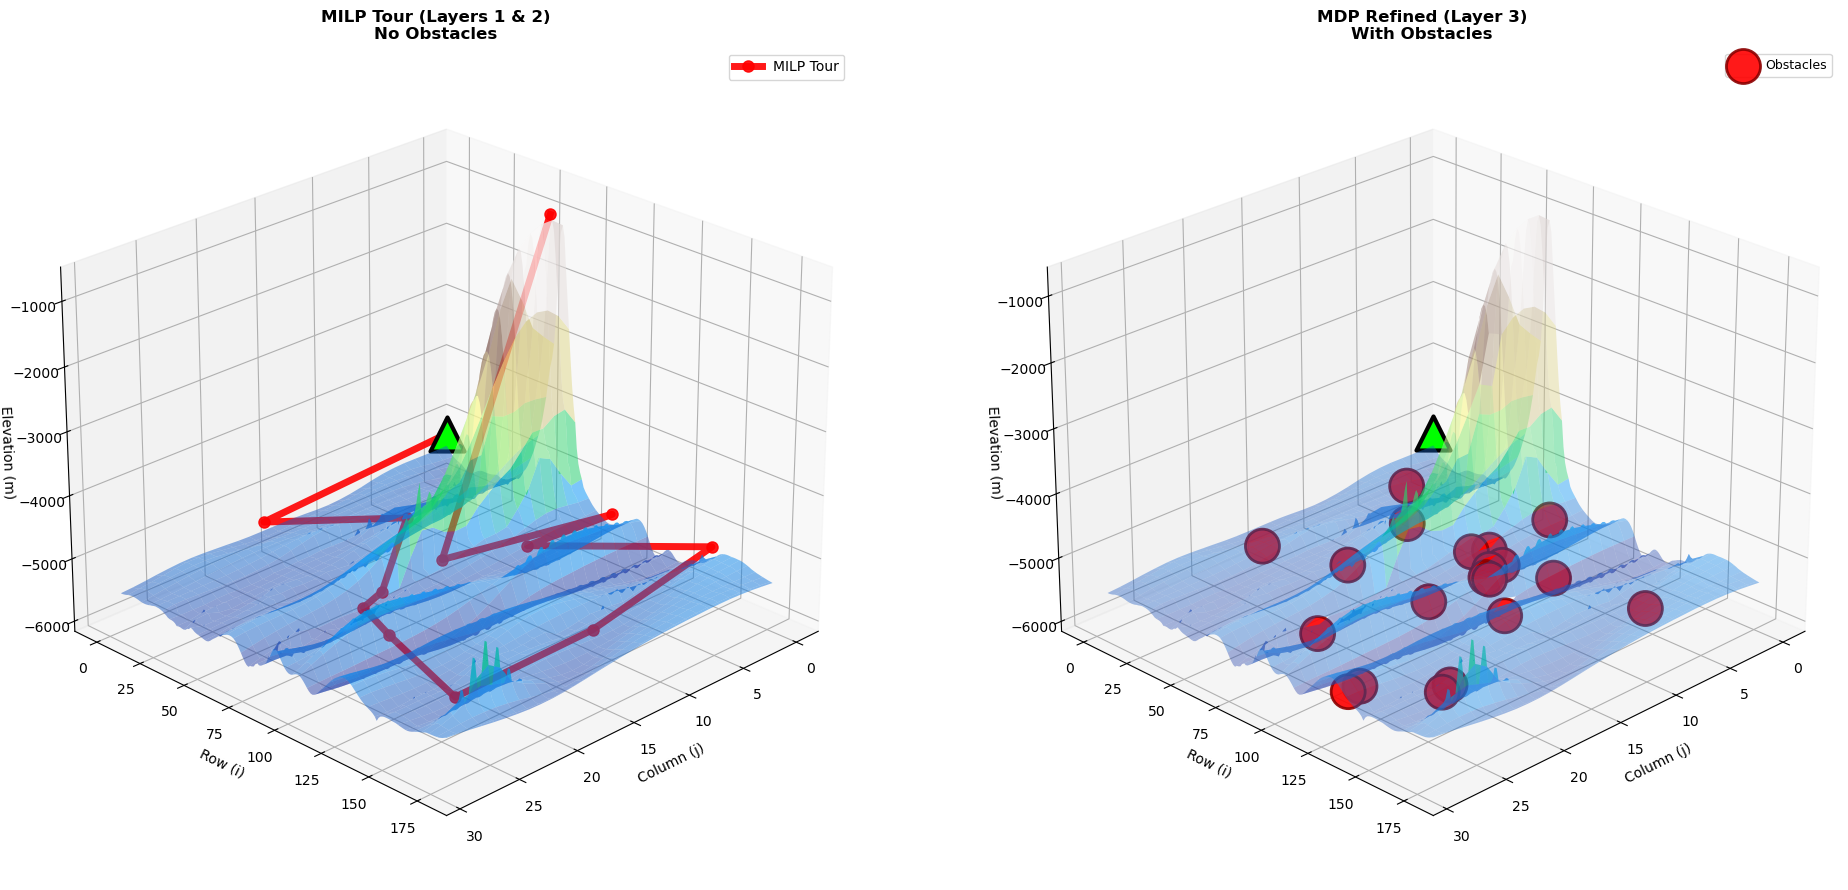

In [8]:
print("\n" + "=" * 70)
print("COMPARISON: MILP Tour vs MDP Refined")
print("=" * 70)
 
fig = plt.figure(figsize=(20, 9))
 
# LEFT: MILP Tour (no obstacles)
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(Xg, Yg, Z_clean, cmap='terrain', alpha=0.5, linewidth=0)
ax1.plot(tour_x, tour_y, tour_z, color='red', linewidth=5, 
        label='MILP Tour', alpha=0.9, marker='o', markersize=8)
ax1.scatter([tour_x[0]], [tour_y[0]], [tour_z[0]], 
           c='lime', s=600, marker='^', edgecolors='black', linewidth=3)
ax1.set_title('MILP Tour (Layers 1 & 2)\nNo Obstacles', fontsize=12, fontweight='bold')
ax1.set_xlabel('Column (j)', fontsize=10)
ax1.set_ylabel('Row (i)', fontsize=10)
ax1.set_zlabel('Elevation (m)', fontsize=10)
ax1.legend(fontsize=10)
ax1.view_init(elev=25, azim=45)
 
# RIGHT: MDP Refined (with obstacles)
ax2 = fig.add_subplot(122, projection='3d')
Z_display = Z_with_obstacles.copy()
Z_display[obstacle_mask] = np.nan
ax2.plot_surface(Xg, Yg, Z_display, cmap='terrain', alpha=0.4, linewidth=0)
 
# Obstacles
if num_obstacles > 0:
    obs_z = np.full(len(obstacle_coords), normal_min)
    ax2.scatter(obstacle_coords[:, 1], obstacle_coords[:, 0], obs_z, 
               c='red', s=600, marker='o', edgecolors='darkred', 
               linewidth=2, alpha=0.9, label='Obstacles')
 
# MDP paths
colors = plt.cm.rainbow(np.linspace(0, 1, len(tour_sequence) - 1))
for idx in range(len(tour_sequence) - 1):
    start, end = tour_sequence[idx], tour_sequence[idx + 1]
    if (start, end) in refined_paths:
        fine_path = refined_paths[(start, end)]
        path_x = [p[1] / mdp.refinement_factor for p in fine_path]
        path_y = [p[0] / mdp.refinement_factor for p in fine_path]
        path_z = [mdp.get_elevation(*p) + 200 for p in fine_path]
        ax2.plot(path_x, path_y, path_z, color=colors[idx], linewidth=3, alpha=0.9)
 
ax2.scatter([tour_x[0]], [tour_y[0]], [tour_z[0]], 
           c='lime', s=600, marker='^', edgecolors='black', linewidth=3)
ax2.set_title('MDP Refined (Layer 3)\nWith Obstacles', fontsize=12, fontweight='bold')
ax2.set_xlabel('Column (j)', fontsize=10)
ax2.set_ylabel('Row (i)', fontsize=10)
ax2.set_zlabel('Elevation (m)', fontsize=10)
ax2.legend(fontsize=9)
ax2.view_init(elev=25, azim=45)
 
plt.tight_layout()
plt.show()

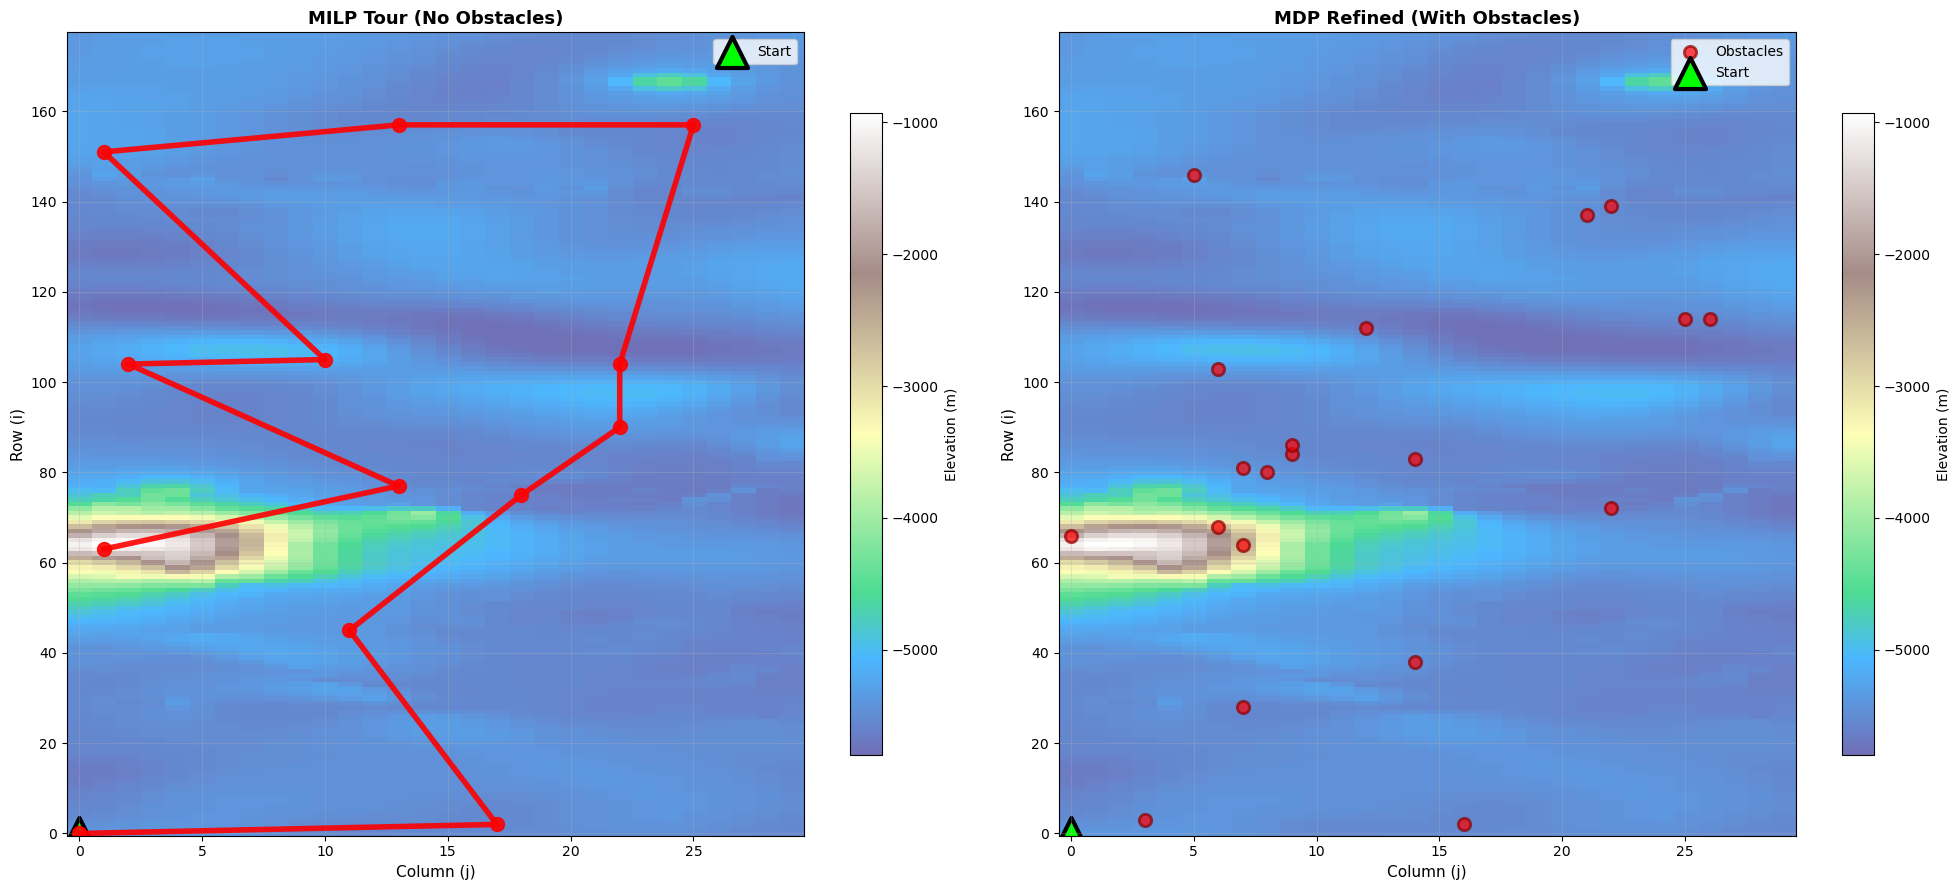

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
 
# LEFT: MILP Tour
im1 = ax1.imshow(Z_clean, cmap='terrain', origin='lower', aspect='auto', alpha=0.7)
plt.colorbar(im1, ax=ax1, label='Elevation (m)', shrink=0.8)
ax1.plot(tour_x, tour_y, color='red', linewidth=4, alpha=0.9, marker='o', markersize=10)
ax1.scatter([tour_x[0]], [tour_y[0]], c='lime', s=500, marker='^', 
           edgecolors='black', linewidth=3, label='Start')
ax1.set_title('MILP Tour (No Obstacles)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Column (j)', fontsize=11)
ax1.set_ylabel('Row (i)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
 
# RIGHT: MDP with obstacles
im2 = ax2.imshow(Z_clean, cmap='terrain', origin='lower', aspect='auto', alpha=0.7)
plt.colorbar(im2, ax=ax2, label='Elevation (m)', shrink=0.8)
 
# Obstacles
if num_obstacles > 0:
    ax2.scatter(obstacle_coords[:, 1], obstacle_coords[:, 0], 
               c='red', s=80, marker='o', edgecolors='darkred', 
               linewidth=2, alpha=0.7, label='Obstacles', zorder=200)
 
# MDP paths
colors = plt.cm.rainbow(np.linspace(0, 1, len(tour_sequence) - 1))
for idx in range(len(tour_sequence) - 1):
    start, end = tour_sequence[idx], tour_sequence[idx + 1]
    if (start, end) in refined_paths:
        fine_path = refined_paths[(start, end)]
        path_x = [p[1] / mdp.refinement_factor for p in fine_path]
        path_y = [p[0] / mdp.refinement_factor for p in fine_path]
        ax2.plot(path_x, path_y, color=colors[idx], linewidth=3, alpha=0.9)
 
ax2.scatter([tour_x[0]], [tour_y[0]], c='lime', s=500, marker='^', 
           edgecolors='black', linewidth=3, label='Start')
ax2.set_title('MDP Refined (With Obstacles)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Column (j)', fontsize=11)
ax2.set_ylabel('Row (i)', fontsize=11)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

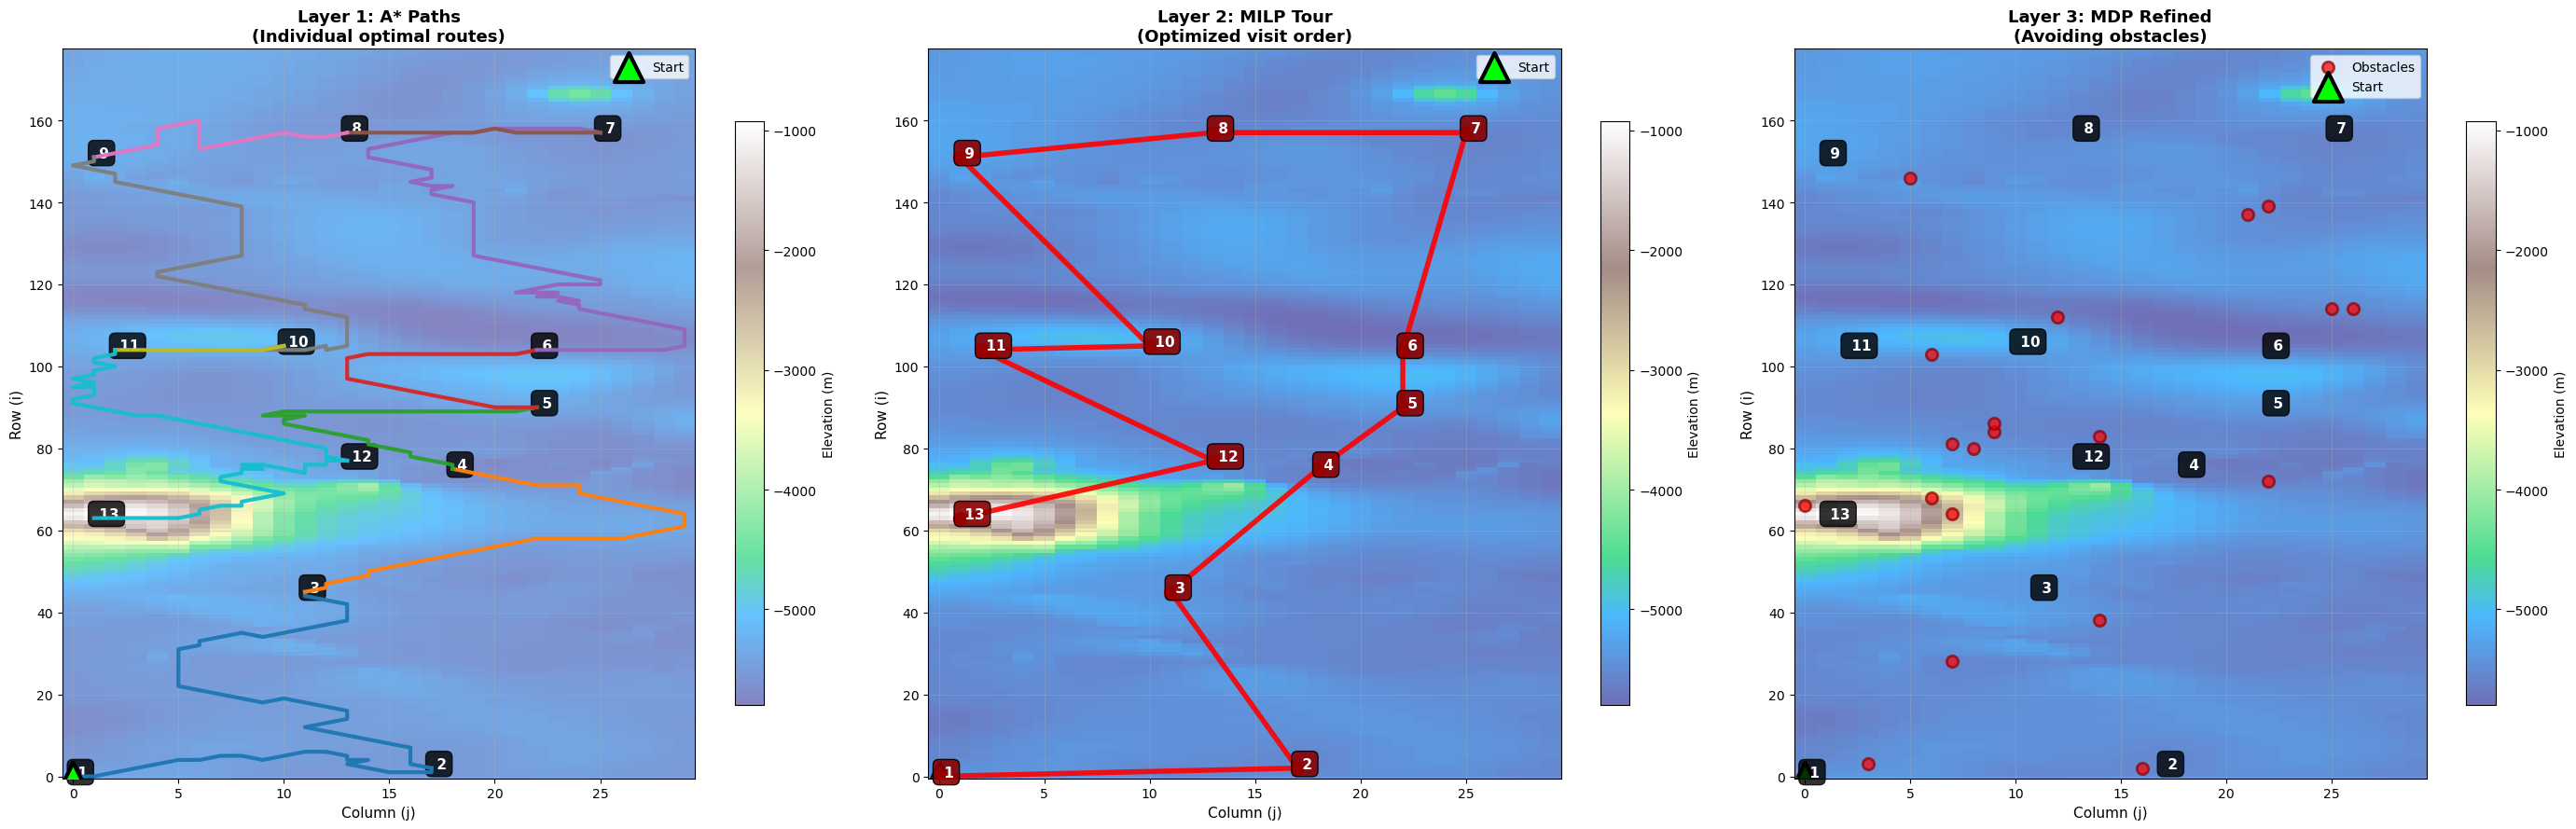


THREE-LAYER COMPARISON
LEFT   (Layer 1): A* paths - Individual optimal routes between waypoints
MIDDLE (Layer 2): MILP tour - Optimized sequence connecting waypoints
RIGHT  (Layer 3): MDP paths - Refined routes avoiding obstacles


In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(28, 9))

# ===== LEFT: A* PATHS =====
im1 = ax1.imshow(Z_clean, cmap='terrain', origin='lower', aspect='auto', alpha=0.6)
plt.colorbar(im1, ax=ax1, label='Elevation (m)', shrink=0.8)

# Plot individual A* paths
colors_astar = plt.cm.tab10(np.linspace(0, 1, len(tour_sequence) - 1))

for idx in range(len(tour_sequence) - 1):
    start_node = tour_sequence[idx]
    end_node = tour_sequence[idx + 1]
    
    if (start_node, end_node) in path_matrix:
        astar_path = path_matrix[(start_node, end_node)]
        path_x = [p[1] for p in astar_path]
        path_y = [p[0] for p in astar_path]
        
        ax1.plot(path_x, path_y, color=colors_astar[idx], linewidth=3, 
               alpha=0.96, zorder=100)

# Labels
for i, node in enumerate(tour_sequence):
    ax1.text(node[1], node[0], f' {i+1}', fontsize=11, 
           fontweight='bold', color='white', 
           bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.8))

# Start
ax1.scatter([tour_x[0]], [tour_y[0]], c='lime', s=500, marker='^', 
          edgecolors='black', linewidth=3, label='Start', zorder=102)

ax1.set_title('Layer 1: A* Paths\n(Individual optimal routes)', 
            fontsize=13, fontweight='bold')
ax1.set_xlabel('Column (j)', fontsize=11)
ax1.set_ylabel('Row (i)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ===== MIDDLE: MILP TOUR =====
im2 = ax2.imshow(Z_clean, cmap='terrain', origin='lower', aspect='auto', alpha=0.7)
plt.colorbar(im2, ax=ax2, label='Elevation (m)', shrink=0.8)

ax2.plot(tour_x, tour_y, color='red', linewidth=4, alpha=0.9, marker='o', markersize=10)

# Labels
for i, node in enumerate(tour_sequence):
    ax2.text(node[1], node[0], f' {i+1}', fontsize=11, 
           fontweight='bold', color='white', 
           bbox=dict(boxstyle='round,pad=0.4', facecolor='darkred', alpha=0.9))

# Start
ax2.scatter([tour_x[0]], [tour_y[0]], c='lime', s=500, marker='^', 
           edgecolors='black', linewidth=3, label='Start')

ax2.set_title('Layer 2: MILP Tour\n(Optimized visit order)', 
            fontsize=13, fontweight='bold')
ax2.set_xlabel('Column (j)', fontsize=11)
ax2.set_ylabel('Row (i)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# ===== RIGHT: MDP WITH OBSTACLES =====
im3 = ax3.imshow(Z_clean, cmap='terrain', origin='lower', aspect='auto', alpha=0.7)
plt.colorbar(im3, ax=ax3, label='Elevation (m)', shrink=0.8)

# Obstacles
if num_obstacles > 0:
    ax3.scatter(obstacle_coords[:, 1], obstacle_coords[:, 0], 
               c='red', s=80, marker='o', edgecolors='darkred', 
               linewidth=2, alpha=0.7, label='Obstacles', zorder=200)

# MDP paths
colors_mdp = plt.cm.rainbow(np.linspace(0, 1, len(tour_sequence) - 1))
for idx in range(len(tour_sequence) - 1):
    start, end = tour_sequence[idx], tour_sequence[idx + 1]
    if (start, end) in refined_paths:
        fine_path = refined_paths[(start, end)]
        path_x = [p[1] / mdp.refinement_factor for p in fine_path]
        path_y = [p[0] / mdp.refinement_factor for p in fine_path]
        ax3.plot(path_x, path_y, color=colors_mdp[idx], linewidth=3, alpha=0.9)

# Labels
for i, node in enumerate(tour_sequence):
    ax3.text(node[1], node[0], f' {i+1}', fontsize=11, 
           fontweight='bold', color='white', 
           bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.8))

# Start
ax3.scatter([tour_x[0]], [tour_y[0]], c='lime', s=500, marker='^', 
           edgecolors='black', linewidth=3, label='Start')

ax3.set_title('Layer 3: MDP Refined\n(Avoiding obstacles)', 
            fontsize=13, fontweight='bold')
ax3.set_xlabel('Column (j)', fontsize=11)
ax3.set_ylabel('Row (i)', fontsize=11)
ax3.legend(fontsize=10, loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("THREE-LAYER COMPARISON")
print("=" * 70)
print("LEFT   (Layer 1): A* paths - Individual optimal routes between waypoints")
print("MIDDLE (Layer 2): MILP tour - Optimized sequence connecting waypoints")
print("RIGHT  (Layer 3): MDP paths - Refined routes avoiding obstacles")
print("=" * 70)

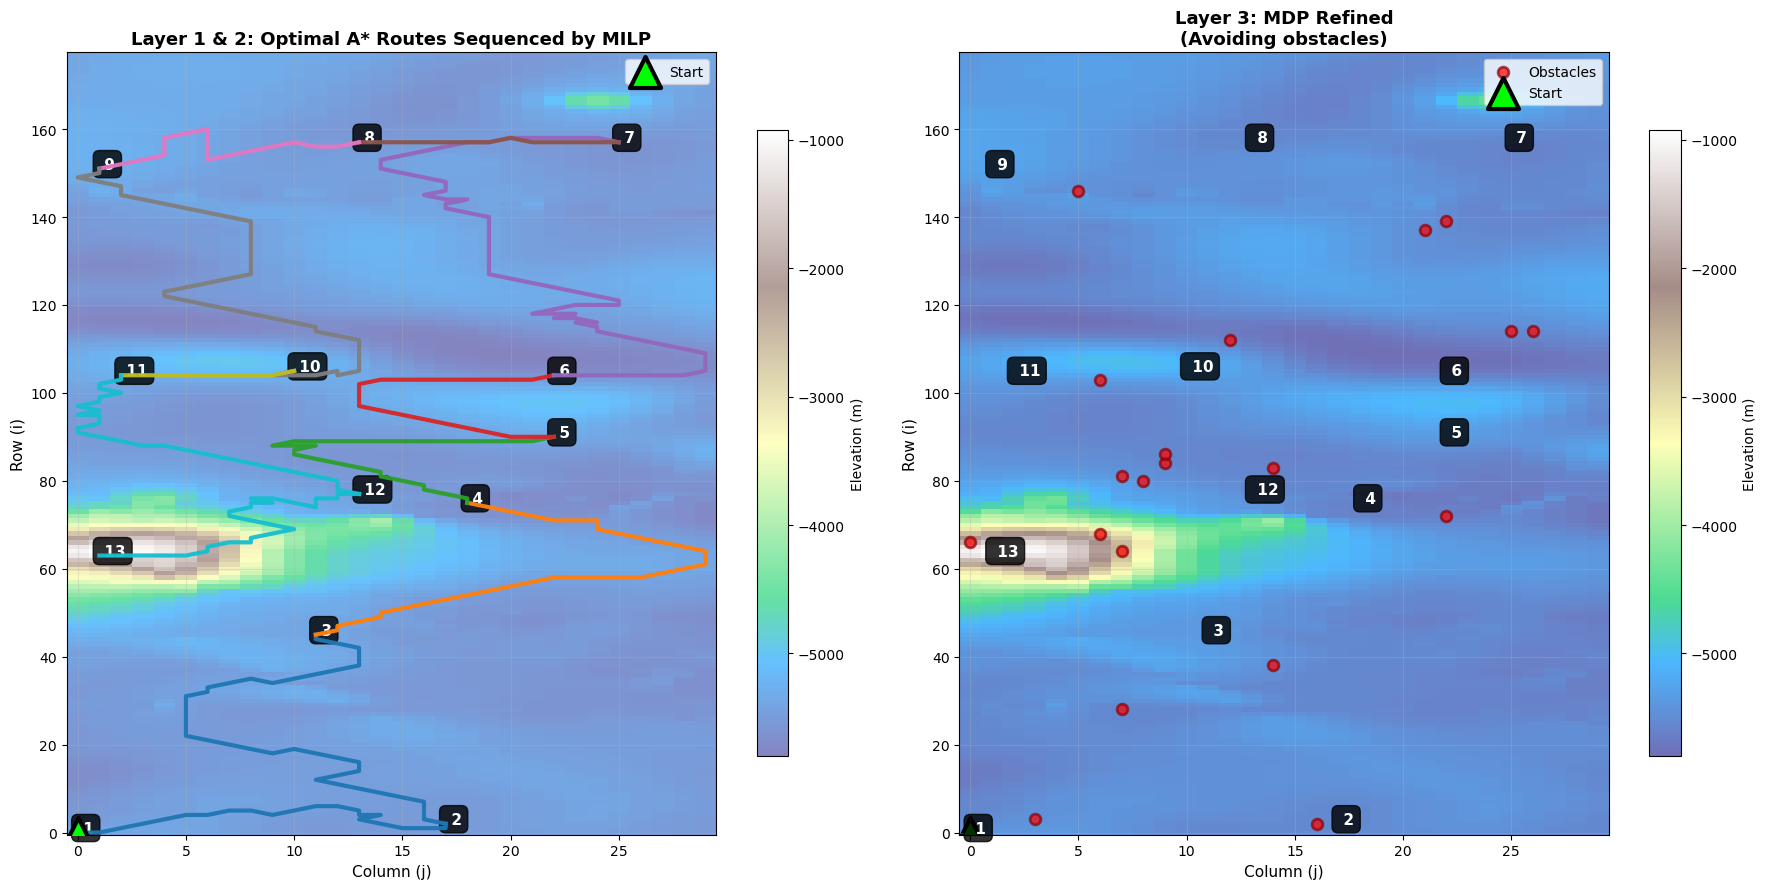


THREE-LAYER COMPARISON
LEFT   (Layer 1): A* paths - Individual optimal routes between waypoints
MIDDLE (Layer 2): MILP tour - Optimized sequence connecting waypoints
RIGHT  (Layer 3): MDP paths - Refined routes avoiding obstacles


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

# ===== LEFT: A* PATHS =====
im1 = ax1.imshow(Z_clean, cmap='terrain', origin='lower', aspect='auto', alpha=0.6)
plt.colorbar(im1, ax=ax1, label='Elevation (m)', shrink=0.8)

# Plot individual A* paths
colors_astar = plt.cm.tab10(np.linspace(0, 1, len(tour_sequence) - 1))

for idx in range(len(tour_sequence) - 1):
    start_node = tour_sequence[idx]
    end_node = tour_sequence[idx + 1]
    
    if (start_node, end_node) in path_matrix:
        astar_path = path_matrix[(start_node, end_node)]
        path_x = [p[1] for p in astar_path]
        path_y = [p[0] for p in astar_path]
        
        ax1.plot(path_x, path_y, color=colors_astar[idx], linewidth=3, 
               alpha=0.96, zorder=100)

# Labels
for i, node in enumerate(tour_sequence):
    ax1.text(node[1], node[0], f' {i+1}', fontsize=11, 
           fontweight='bold', color='white', 
           bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.8))

# Start
ax1.scatter([tour_x[0]], [tour_y[0]], c='lime', s=500, marker='^', 
          edgecolors='black', linewidth=3, label='Start', zorder=102)

ax1.set_title('Layer 1 & 2: Optimal A* Routes Sequenced by MILP', 
            fontsize=13, fontweight='bold')
ax1.set_xlabel('Column (j)', fontsize=11)
ax1.set_ylabel('Row (i)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)


# ===== RIGHT: MDP WITH OBSTACLES =====
im2 = ax2.imshow(Z_clean, cmap='terrain', origin='lower', aspect='auto', alpha=0.7)
plt.colorbar(im2, ax=ax2, label='Elevation (m)', shrink=0.8)

# Obstacles
if num_obstacles > 0:
    ax2.scatter(obstacle_coords[:, 1], obstacle_coords[:, 0], 
               c='red', s=60, marker='o', edgecolors='darkred', 
               linewidth=2, alpha=0.7, label='Obstacles', zorder=200)

# MDP paths
colors_mdp = plt.cm.rainbow(np.linspace(0, 1, len(tour_sequence) - 1))
for idx in range(len(tour_sequence) - 1):
    start, end = tour_sequence[idx], tour_sequence[idx + 1]
    if (start, end) in refined_paths:
        fine_path = refined_paths[(start, end)]
        path_x = [p[1] / mdp.refinement_factor for p in fine_path]
        path_y = [p[0] / mdp.refinement_factor for p in fine_path]
        ax2.plot(path_x, path_y, color=colors_mdp[idx], linewidth=3, alpha=0.9)

# Labels
for i, node in enumerate(tour_sequence):
    ax2.text(node[1], node[0], f' {i+1}', fontsize=11, 
           fontweight='bold', color='white', 
           bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.8))

# Start
ax2.scatter([tour_x[0]], [tour_y[0]], c='lime', s=500, marker='^', 
           edgecolors='black', linewidth=3, label='Start')

ax2.set_title('Layer 3: MDP Refined\n(Avoiding obstacles)', 
            fontsize=13, fontweight='bold')
ax2.set_xlabel('Column (j)', fontsize=11)
ax2.set_ylabel('Row (i)', fontsize=11)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("THREE-LAYER COMPARISON")
print("=" * 70)
print("LEFT   (Layer 1): A* paths - Individual optimal routes between waypoints")
print("MIDDLE (Layer 2): MILP tour - Optimized sequence connecting waypoints")
print("RIGHT  (Layer 3): MDP paths - Refined routes avoiding obstacles")
print("=" * 70)

In [12]:
print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
 
print("\n1. GRID INFORMATION:")
print(f"   Coarse grid: {Z_clean.shape[0]} × {Z_clean.shape[1]} cells")
print(f"   Fine grid: {mdp.fine_rows} × {mdp.fine_cols} cells")
print(f"   Refinement factor: {mdp.refinement_factor}")
 
print("\n2. PLANNING RESULTS:")
print(f"   Waypoints to visit: {len(tour_sequence)}")
print(f"   Tour segments: {len(tour_sequence) - 1}")
print(f"   Obstacles: {num_obstacles}")
 
print("\n3. LAYER 1 - A* PAIRWISE COSTS:")
print(f"   Total path segments computed: {len(path_matrix)}")
 
print("\n4. LAYER 2 - MILP TOUR:")
print(f"   Visit order: {' → '.join([str(n) for n in tour_sequence])}")
 
print("\n5. LAYER 3 - MDP REFINEMENT:")
total_fine_nodes = sum(len(refined_paths[key]) for key in refined_paths)
print(f"   Total fine grid nodes: {total_fine_nodes}")
print(f"   Refined segments: {len(refined_paths)}")
 
print("\n6. COST ANALYSIS:")
for i in range(len(tour_sequence) - 1):
    start = tour_sequence[i]
    end = tour_sequence[i + 1]
    if (start, end) in refined_distributions:
        stats = refined_distributions[(start, end)]
        print(f"   Segment {i+1} ({start} → {end}):")
        print(f"      Cost: {stats['mean']:.2f} ± {stats['std']:.2f}")
        print(f"      95% CI: [{stats['ci_lower']:.2f}, {stats['ci_upper']:.2f}]")
 
print("\n" + "=" * 70)
print("✓ Notebook complete!")
print("=" * 70)


SUMMARY STATISTICS

1. GRID INFORMATION:
   Coarse grid: 178 × 30 cells
   Fine grid: 532 × 88 cells
   Refinement factor: 3

2. PLANNING RESULTS:
   Waypoints to visit: 13
   Tour segments: 12
   Obstacles: 20

3. LAYER 1 - A* PAIRWISE COSTS:
   Total path segments computed: 169

4. LAYER 2 - MILP TOUR:
   Visit order: (0, 0) → (2, 17) → (45, 11) → (75, 18) → (90, 22) → (104, 22) → (157, 25) → (157, 13) → (151, 1) → (105, 10) → (104, 2) → (77, 13) → (63, 1)

5. LAYER 3 - MDP REFINEMENT:
   Total fine grid nodes: 0
   Refined segments: 0

6. COST ANALYSIS:

✓ Notebook complete!



SIMULATING REVEALED INTERPOLATION UNCERTAINTY

Simulating path execution with revealed interpolation costs...

Total Expected Cost: 0.00
Total Realized Cost: 0.00
Total Deviation: +0.00

Generating revealed uncertainty visualization...


ValueError: zero-size array to reduction operation minimum which has no identity

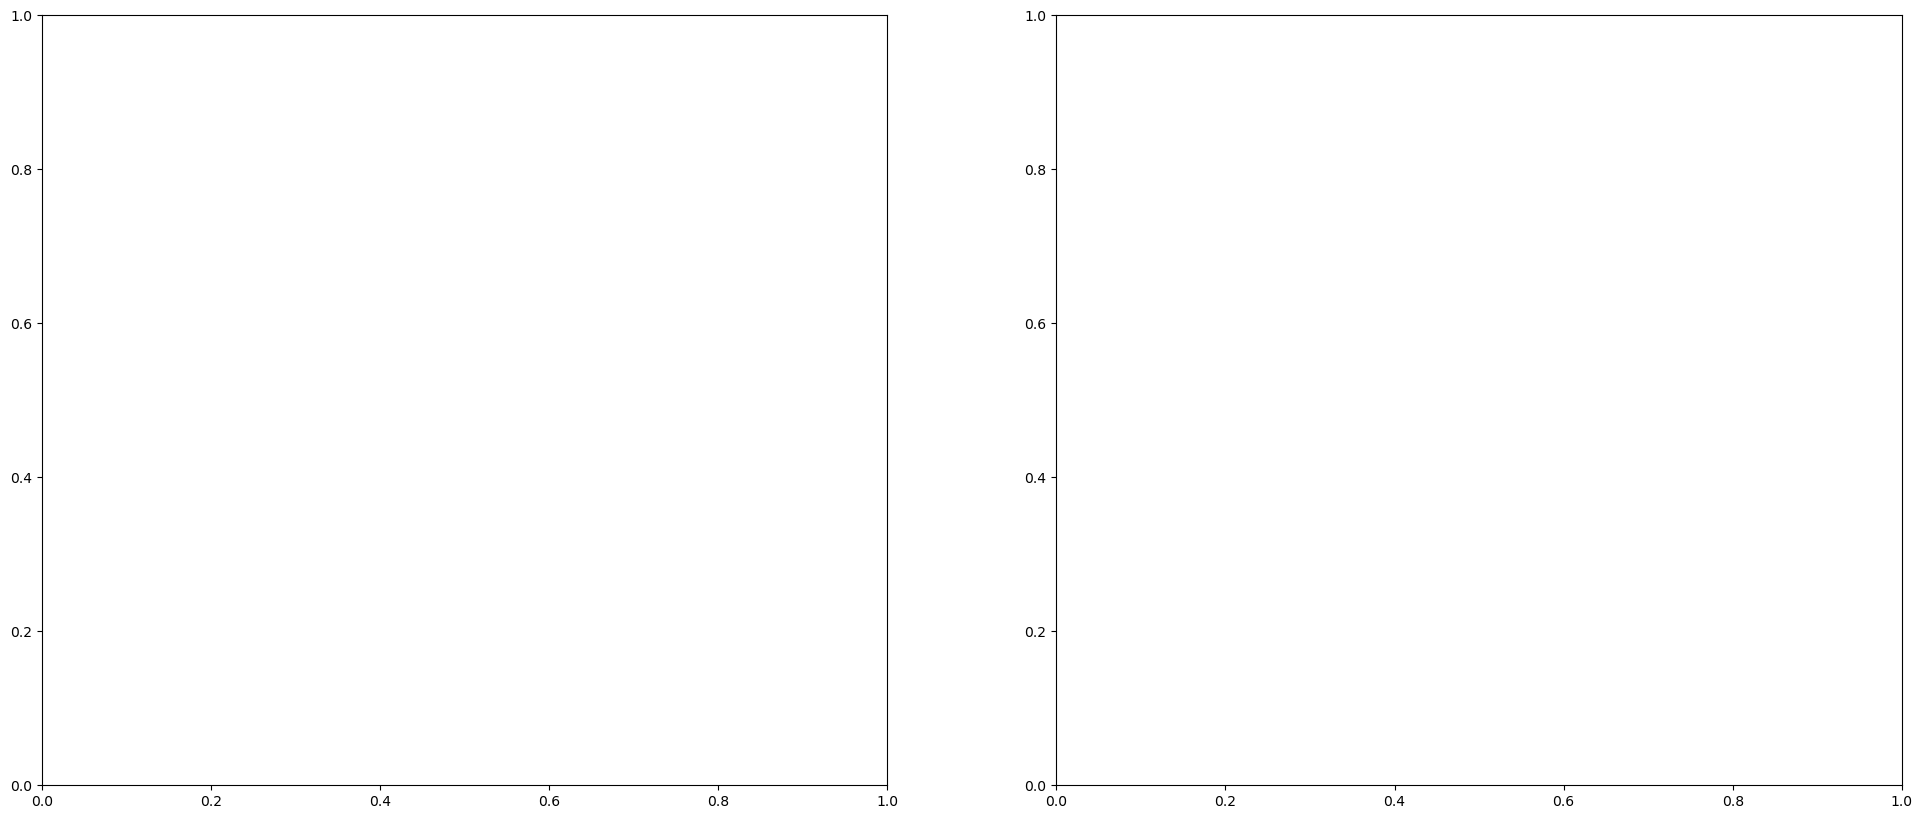

In [13]:
"""
VISUALIZATION: Revealed Interpolation Uncertainty
==================================================

Shows how the stochastic interpolation penalty φ ~ N(μ_φ, σ_φ²) affects
the actual cost as the rover traverses the refined MDP path.

Background color = revealed noise/uncertainty at each point
Path = actual trajectory adapting to these costs
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches

# ============================================================================
# CELL: Generate Realized Noise for MDP Path
# ============================================================================

print("\n" + "=" * 70)
print("SIMULATING REVEALED INTERPOLATION UNCERTAINTY")
print("=" * 70)

# For each refined path segment, generate actual realized φ values
realized_phi_map = np.zeros(Z_clean.shape)  # Map of realized penalties
path_coverage = np.zeros(Z_clean.shape, dtype=bool)  # Which cells were traversed

# Simulate one realization of the stochastic path
np.random.seed(456)  # Different seed for realization

total_realized_cost = 0.0
segment_realized_costs = {}

print("\nSimulating path execution with revealed interpolation costs...")

for idx in range(len(tour_sequence) - 1):
    start_coarse = tour_sequence[idx]
    end_coarse = tour_sequence[idx + 1]
    
    if (start_coarse, end_coarse) not in refined_paths:
        continue
    
    fine_path = refined_paths[(start_coarse, end_coarse)]
    stats = refined_distributions[(start_coarse, end_coarse)]
    
    # Simulate realized cost for this segment
    segment_elevation_cost = 0.0
    segment_phi_cost = 0.0
    
    for i in range(len(fine_path) - 1):
        state = fine_path[i]
        next_state = fine_path[i + 1]
        
        # Elevation cost (deterministic)
        Z_s = mdp.get_elevation(*state)
        Z_s_prime = mdp.get_elevation(*next_state)
        elevation_cost = mdp.m * mdp.g * abs(Z_s_prime - Z_s)
        segment_elevation_cost += elevation_cost
        
        # Interpolation penalty (stochastic)
        is_coarse_s = mdp.is_coarse_node(*state)
        is_coarse_s_prime = mdp.is_coarse_node(*next_state)
        
        if not (is_coarse_s and is_coarse_s_prime):
            # Fine transition - sample realized φ
            phi_realized = np.random.normal(mdp.phi_mean, mdp.phi_std)
            segment_phi_cost += phi_realized
            
            # Mark this on the map (convert fine to coarse coords)
            coarse_i = next_state[0] // mdp.refinement_factor
            coarse_j = next_state[1] // mdp.refinement_factor
            
            if 0 <= coarse_i < Z_clean.shape[0] and 0 <= coarse_j < Z_clean.shape[1]:
                # Store the revealed noise (deviation from expected)
                realized_phi_map[coarse_i, coarse_j] = phi_realized - mdp.phi_mean
                path_coverage[coarse_i, coarse_j] = True
    
    segment_total_cost = segment_elevation_cost + segment_phi_cost
    segment_realized_costs[(start_coarse, end_coarse)] = {
        'realized_cost': segment_total_cost,
        'expected_cost': stats['mean'],
        'elevation_cost': segment_elevation_cost,
        'phi_cost': segment_phi_cost
    }
    
    total_realized_cost += segment_total_cost
    
    print(f"Segment {idx+1}: Expected {stats['mean']:.2f}, " + 
          f"Realized {segment_total_cost:.2f}, " +
          f"Deviation {segment_total_cost - stats['mean']:+.2f}")

# Calculate total expected cost
total_expected_cost = sum(stats['mean'] for stats in refined_distributions.values())

print(f"\nTotal Expected Cost: {total_expected_cost:.2f}")
print(f"Total Realized Cost: {total_realized_cost:.2f}")
print(f"Total Deviation: {total_realized_cost - total_expected_cost:+.2f}")


# ============================================================================
# CELL: Visualize Revealed Noise as Background
# ============================================================================

print("\nGenerating revealed uncertainty visualization...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# ===== LEFT: Revealed Noise/Uncertainty Map =====

# Create masked array - only show noise where path traversed
noise_display = np.ma.masked_where(~path_coverage, realized_phi_map)

# Use diverging colormap centered at 0
# Negative = better than expected (blue)
# Positive = worse than expected (red)
vmax = max(abs(realized_phi_map[path_coverage].min()), 
           abs(realized_phi_map[path_coverage].max()))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im1 = ax1.imshow(noise_display, cmap='RdBu_r', norm=norm, 
                origin='lower', aspect='auto', alpha=0.9)
cbar1 = plt.colorbar(im1, ax=ax1, label='Revealed Interpolation Noise φ - E[φ]', 
                     shrink=0.8)

# Overlay MDP path
colors = plt.cm.rainbow(np.linspace(0, 1, len(tour_sequence) - 1))
for idx in range(len(tour_sequence) - 1):
    start, end = tour_sequence[idx], tour_sequence[idx + 1]
    if (start, end) in refined_paths:
        fine_path = refined_paths[(start, end)]
        path_x = [p[1] / mdp.refinement_factor for p in fine_path]
        path_y = [p[0] / mdp.refinement_factor for p in fine_path]
        ax1.plot(path_x, path_y, color=colors[idx], linewidth=3, 
                alpha=0.8, zorder=100)

# Start marker
ax1.scatter([tour_sequence[0][1]], [tour_sequence[0][0]], 
           c='lime', s=600, marker='^', edgecolors='black', 
           linewidth=3, label='Start', zorder=101)

ax1.set_title('Revealed Interpolation Uncertainty Along Path\n' + 
             'Red = Worse than expected | Blue = Better than expected',
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Column (j)', fontsize=12)
ax1.set_ylabel('Row (i)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, color='gray', linestyle='--')

# ===== RIGHT: Cost Evolution Along Path =====

# Collect cumulative costs along the path
path_distance = []
expected_cumulative = []
realized_cumulative = []

cumulative_expected = 0.0
cumulative_realized = 0.0
distance = 0

for idx in range(len(tour_sequence) - 1):
    start, end = tour_sequence[idx], tour_sequence[idx + 1]
    
    if (start, end) in refined_paths and (start, end) in segment_realized_costs:
        fine_path = refined_paths[(start, end)]
        stats = refined_distributions[(start, end)]
        realized = segment_realized_costs[(start, end)]
        
        # Add segment
        cumulative_expected += stats['mean']
        cumulative_realized += realized['realized_cost']
        distance += len(fine_path)
        
        path_distance.append(distance)
        expected_cumulative.append(cumulative_expected)
        realized_cumulative.append(cumulative_realized)

# Plot cumulative costs
ax2.plot(path_distance, expected_cumulative, color='blue', linewidth=3, 
        label='Expected Cost E[c]', linestyle='--', alpha=0.8)
ax2.plot(path_distance, realized_cumulative, color='red', linewidth=3, 
        label='Realized Cost (with noise)', alpha=0.9)

# Fill between to show deviation
ax2.fill_between(path_distance, expected_cumulative, realized_cumulative, 
                alpha=0.3, color='orange', label='Cost Deviation')

# Add confidence interval
if len(path_distance) > 0:
    total_std = np.sqrt(sum(s['variance'] for s in refined_distributions.values()))
    upper_bound = [e + 1.96 * total_std * (d / path_distance[-1]) 
                   for e, d in zip(expected_cumulative, path_distance)]
    lower_bound = [e - 1.96 * total_std * (d / path_distance[-1]) 
                   for e, d in zip(expected_cumulative, path_distance)]
    
    ax2.fill_between(path_distance, lower_bound, upper_bound, 
                    alpha=0.2, color='blue', label='95% Confidence Interval')

ax2.set_title('Cumulative Cost Evolution Along Path\n' + 
             f'Final: Expected {total_expected_cost:.1f}, ' + 
             f'Realized {total_realized_cost:.1f}',
             fontsize=14, fontweight='bold')
ax2.set_xlabel('Path Progress (fine grid cells)', fontsize=12)
ax2.set_ylabel('Cumulative Cost', fontsize=12)
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Revealed uncertainty visualization complete")


# ============================================================================
# CELL: Histogram of Realized vs Expected Costs
# ============================================================================

print("\nGenerating cost distribution comparison...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT: Per-segment cost comparison
segment_numbers = list(range(1, len(tour_sequence)))
expected_costs = [refined_distributions[(tour_sequence[i], tour_sequence[i+1])]['mean'] 
                 for i in range(len(tour_sequence) - 1) 
                 if (tour_sequence[i], tour_sequence[i+1]) in refined_distributions]
realized_costs = [segment_realized_costs[(tour_sequence[i], tour_sequence[i+1])]['realized_cost']
                 for i in range(len(tour_sequence) - 1) 
                 if (tour_sequence[i], tour_sequence[i+1]) in segment_realized_costs]

x = np.arange(len(segment_numbers))
width = 0.35

bars1 = ax1.bar(x - width/2, expected_costs, width, label='Expected Cost', 
               color='blue', alpha=0.7)
bars2 = ax1.bar(x + width/2, realized_costs, width, label='Realized Cost', 
               color='red', alpha=0.7)

ax1.set_xlabel('Segment Number', fontsize=12)
ax1.set_ylabel('Cost', fontsize=12)
ax1.set_title('Expected vs Realized Cost Per Segment', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(segment_numbers)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# RIGHT: Distribution of noise values
phi_noise_values = realized_phi_map[path_coverage]

ax2.hist(phi_noise_values, bins=30, color='purple', alpha=0.7, edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Expected (μ=0)')
ax2.axvline(phi_noise_values.mean(), color='green', linestyle='--', linewidth=2, 
           label=f'Realized Mean ({phi_noise_values.mean():.3f})')

ax2.set_xlabel('Interpolation Noise (φ - E[φ])', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Revealed Interpolation Noise', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nNoise Statistics:")
print(f"  Mean: {phi_noise_values.mean():.4f} (expected: 0)")
print(f"  Std:  {phi_noise_values.std():.4f} (expected: {mdp.phi_std:.4f})")
print(f"  Min:  {phi_noise_values.min():.4f}")
print(f"  Max:  {phi_noise_values.max():.4f}")


# ============================================================================
# CELL: Animation-Style Visualization (Optional)
# ============================================================================

print("\nGenerating progressive revelation visualization...")

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

# Show progressive revelation at different stages
progress_points = [0.2, 0.4, 0.6, 0.8, 1.0]

for plot_idx, progress in enumerate(progress_points):
    ax = axes[plot_idx]
    
    # Only show noise revealed up to this point
    cutoff_distance = int(path_distance[-1] * progress) if path_distance else 0
    
    partial_noise = np.ma.masked_array(realized_phi_map, mask=True)
    partial_coverage = np.zeros_like(path_coverage)
    
    current_distance = 0
    for idx in range(len(tour_sequence) - 1):
        start, end = tour_sequence[idx], tour_sequence[idx + 1]
        
        if (start, end) not in refined_paths:
            continue
        
        fine_path = refined_paths[(start, end)]
        
        if current_distance >= cutoff_distance:
            break
        
        for i in range(len(fine_path) - 1):
            if current_distance >= cutoff_distance:
                break
            
            state = fine_path[i]
            next_state = fine_path[i + 1]
            
            coarse_i = next_state[0] // mdp.refinement_factor
            coarse_j = next_state[1] // mdp.refinement_factor
            
            if 0 <= coarse_i < Z_clean.shape[0] and 0 <= coarse_j < Z_clean.shape[1]:
                if path_coverage[coarse_i, coarse_j]:
                    partial_noise.mask[coarse_i, coarse_j] = False
                    partial_coverage[coarse_i, coarse_j] = True
            
            current_distance += 1
    
    # Plot
    im = ax.imshow(partial_noise, cmap='RdBu_r', norm=norm, 
                  origin='lower', aspect='auto', alpha=0.9)
    
    # Path so far
    for idx in range(len(tour_sequence) - 1):
        start, end = tour_sequence[idx], tour_sequence[idx + 1]
        if (start, end) in refined_paths:
            fine_path = refined_paths[(start, end)]
            path_x = [p[1] / mdp.refinement_factor for p in fine_path]
            path_y = [p[0] / mdp.refinement_factor for p in fine_path]
            ax.plot(path_x, path_y, color='black', linewidth=2, alpha=0.5)
    
    ax.set_title(f'Progress: {progress*100:.0f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Column (j)', fontsize=10)
    ax.set_ylabel('Row (i)', fontsize=10)
    ax.grid(True, alpha=0.3)

# Last subplot - legend
axes[-1].axis('off')
legend_elements = [
    mpatches.Patch(color='red', label='Worse than expected (high φ)'),
    mpatches.Patch(color='white', label='As expected'),
    mpatches.Patch(color='blue', label='Better than expected (low φ)'),
    mpatches.Patch(color='gray', label='Not yet revealed', alpha=0.3)
]
axes[-1].legend(handles=legend_elements, loc='center', fontsize=14)
axes[-1].set_title('Noise Revelation Legend', fontsize=14, fontweight='bold')

plt.suptitle('Progressive Revelation of Interpolation Uncertainty', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Progressive revelation visualization complete")

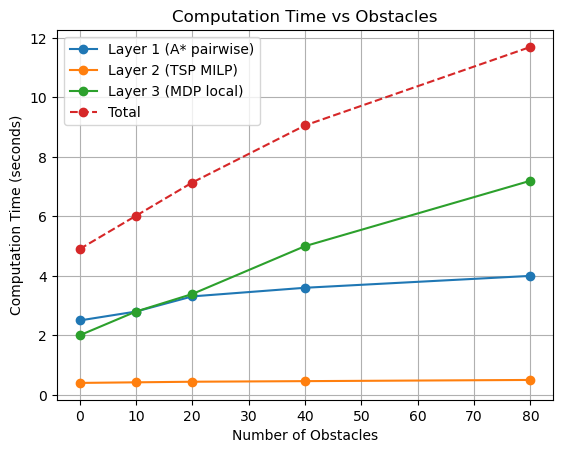

In [ ]:
import matplotlib.pyplot as plt

# Example data — replace with your actual experiment outputs
obstacles = [0, 10, 20, 40, 80]

layer1_times = [2.5, 2.8, 3.31, 3.6, 4.0]   # A* pairwise
layer2_times = [0.4, 0.42, 0.44, 0.46, 0.5] # MILP
layer3_times = [2.0, 2.8, 3.39, 5.0, 7.2]   # MDP local
total_times  = [l1 + l2 + l3 for l1, l2, l3 in zip(layer1_times, layer2_times, layer3_times)]

# Plot
plt.figure()

plt.plot(obstacles, layer1_times, marker='o', label="Layer 1 (A* pairwise)")
plt.plot(obstacles, layer2_times, marker='o', label="Layer 2 (TSP MILP)")
plt.plot(obstacles, layer3_times, marker='o', label="Layer 3 (MDP local)")
plt.plot(obstacles, total_times, marker='o', linestyle='--', label="Total")

plt.xlabel("Number of Obstacles")
plt.ylabel("Computation Time (seconds)")
plt.title("Computation Time vs Obstacles")

plt.legend()
plt.grid()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches
from vrp_adaptive import compute_pairwise_costs 
 
# ============================================================================
# Simulate Deterministic Path with Revealed Costs
# ============================================================================
 
print("\n" + "=" * 70)
print("SIMULATING DETERMINISTIC PATH WITH STOCHASTIC COSTS")
print("=" * 70)
 
# The deterministic path is just the A* coarse grid path from Layers 1&2
# We'll simulate what happens when this path encounters:
# 1. Obstacles (that it didn't know about)
# 2. Stochastic interpolation penalties
 
np.random.seed(123)  # Same seed as MDP for fair comparison
 
deterministic_cost = 0.0
deterministic_feasible = True
segments_blocked = []


 
print("\nExecuting deterministic path (Layers 1&2 only)...")
print("This path is NOT aware of obstacles!\n")
 
for idx in range(len(tour_sequence) - 1):
    start_coarse = tour_sequence[idx]
    end_coarse = tour_sequence[idx + 1]
    
    if (start_coarse, end_coarse) not in path_matrix:
        continue
    
    # The deterministic path from A*
    coarse_path = path_matrix[(start_coarse, end_coarse)]
    
    # Check if this path hits any obstacles
    segment_blocked = False
    for cell in coarse_path:
        if Z_with_obstacles[cell[0], cell[1]] > 1e5:
            segment_blocked = True
            segments_blocked.append((start_coarse, end_coarse))
            print(f"⚠️  Segment {idx+1} ({start_coarse} → {end_coarse}): "
                  f"BLOCKED by obstacle at {cell}!")
            break
    
    if segment_blocked:
        deterministic_feasible = False
        # In practice, rover would need emergency replanning
        # We'll add a large penalty cost
        deterministic_cost += 1e6  # Effectively infinite
    else:
        # Calculate cost with stochastic penalties
        # Use same interpolation as MDP would see
        segment_cost = cost_matrix[(start_coarse, end_coarse)]
        
        # Add stochastic penalties (simulate what would be revealed)
        # Estimate number of fine transitions this segment would have
        path_length = len(coarse_path)
        estimated_fine_transitions = path_length * mdp.refinement_factor * 2
        
        # Sample stochastic penalties
        total_phi = 0.0
        for _ in range(estimated_fine_transitions):
            phi = np.random.normal(mdp.phi_mean, mdp.phi_std)
            total_phi += phi
        
        realized_segment_cost = segment_cost + total_phi
        deterministic_cost += realized_segment_cost
        
        print(f"✓  Segment {idx+1} ({start_coarse} → {end_coarse}): "
              f"Cost = {realized_segment_cost:.2f} (base {segment_cost:.2f} + "
              f"penalties {total_phi:+.2f})")
 
if deterministic_feasible:
    print(f"\n✓ Deterministic path completed: Total cost = {deterministic_cost:.2f}")
else:
    print(f"\n❌ Deterministic path INFEASIBLE: {len(segments_blocked)} segments blocked!")
    print(f"   Blocked segments: {segments_blocked}")
    print(f"   Total cost (with penalties): {deterministic_cost:.2f}")
 


SIMULATING DETERMINISTIC PATH WITH STOCHASTIC COSTS

Executing deterministic path (Layers 1&2 only)...
This path is NOT aware of obstacles!



NameError: name 'cost_matrix' is not defined